In [34]:
import pandas as pd
import numpy as np

In [35]:
df = pd.read_csv("cleaned_data.csv")

print("Original shape:", df.shape)

Original shape: (50998, 14)


In [36]:
df_model = df.drop(
    columns=[
        "title",           
        "price_per_sqft",  
        "city" 
    ]            
)

print("Shape after dropping columns:", df_model.shape)
print(df_model.columns)

Shape after dropping columns: (50998, 11)
Index(['price', 'area', 'locality', 'property_type', 'bedroom_num',
       'bathroom_num', 'furnished', 'total_floors', 'new_latitude',
       'new_longitude', 'new_pincode'],
      dtype='str')


In [37]:
print(df_model.isnull().sum())

price            0
area             0
locality         0
property_type    0
bedroom_num      0
bathroom_num     0
furnished        0
total_floors     0
new_latitude     0
new_longitude    0
new_pincode      0
dtype: int64


In [38]:
X = df_model.drop(columns=["price"])
y = df_model["price"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (50998, 10)
y shape: (50998,)


In [39]:
y_log = np.log1p(y)

print(y_log.describe())

count    50998.000000
mean        16.336523
std          0.920252
min         10.373522
25%         15.687313
50%         16.300417
75%         16.906979
max         21.487563
Name: price, dtype: float64


In [40]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_log,
    test_size=0.20,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (40798, 10)
X_test : (10200, 10)
y_train: (40798,)
y_test : (10200,)


In [41]:
categorical_features = [
    "locality",
    "property_type",
    "furnished"
]

numerical_features = [
    "area",
    "bedroom_num",
    "bathroom_num",
    "total_floors",
    "new_latitude",
    "new_longitude",
    "new_pincode"
]

In [42]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder


preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

In [43]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

print("\nProcessed data shape:")
print("X_train_processed:", X_train_processed.shape)
print("X_test_processed :", X_test_processed.shape)


Processed data shape:
X_train_processed: (40798, 394)
X_test_processed : (10200, 394)


In [44]:
# Make pincode categorical
X_train["new_pincode"] = X_train["new_pincode"].astype(str)
X_test["new_pincode"] = X_test["new_pincode"].astype(str)

print(X_train["new_pincode"].dtype)
print(X_train["new_pincode"].nunique())

str
83


In [45]:
y_log = np.log1p(y)

In [46]:
import pandas as pd
import numpy as np

def target_encode_oof(
    train_series,
    test_series,
    y_train,
    n_splits=5,
    smoothing=20,
    random_state=42
):
    """
    Leakage-safe target encoding.

    Training:
        Uses out-of-fold encoding so a row's own target
        does not directly determine its encoded value.

    Testing:
        Uses mapping learned from the complete training set.
    """

    from sklearn.model_selection import KFold

    train_series = train_series.reset_index(drop=True)
    test_series = test_series.reset_index(drop=True)
    y_train = pd.Series(y_train).reset_index(drop=True)

    global_mean = y_train.mean()

    oof_encoded = pd.Series(index=train_series.index, dtype=float)

    kfold = KFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=random_state
    )

    for train_idx, valid_idx in kfold.split(train_series):

        fold_data = pd.DataFrame({
            "category": train_series.iloc[train_idx],
            "target": y_train.iloc[train_idx]
        })

        stats = fold_data.groupby("category")["target"].agg(
            ["mean", "count"]
        )

        # Smoothed mean
        stats["encoded"] = (
            (stats["mean"] * stats["count"] +
             global_mean * smoothing)
            /
            (stats["count"] + smoothing)
        )

        mapping = stats["encoded"]

        oof_encoded.iloc[valid_idx] = (
            train_series.iloc[valid_idx]
            .map(mapping)
            .fillna(global_mean)
            .values
        )

    # Mapping using ALL training data for test set
    full_data = pd.DataFrame({
        "category": train_series,
        "target": y_train
    })

    stats = full_data.groupby("category")["target"].agg(
        ["mean", "count"]
    )

    stats["encoded"] = (
        (stats["mean"] * stats["count"] +
         global_mean * smoothing)
        /
        (stats["count"] + smoothing)
    )

    test_encoded = (
        test_series
        .map(stats["encoded"])
        .fillna(global_mean)
    )

    return (
        oof_encoded,
        test_encoded
    )

In [47]:
pincode_train_encoded, pincode_test_encoded = target_encode_oof(
    train_series=X_train["new_pincode"],
    test_series=X_test["new_pincode"],
    y_train=y_train,
    n_splits=5,
    smoothing=20
)

In [48]:
# target_encode_oof resets indices internally; assign by position, not index.
X_train["pincode_target_encoded"] = pincode_train_encoded.to_numpy()
X_test["pincode_target_encoded"] = pincode_test_encoded.to_numpy()

In [49]:
X_train = X_train.drop(columns=["new_pincode"])
X_test = X_test.drop(columns=["new_pincode"])

In [50]:
print(X_train[["pincode_target_encoded"]].head())

       pincode_target_encoded
13595               16.365103
8326                16.759025
11099               15.554241
47416               15.909622
33277               16.231453


In [51]:
from sklearn.cluster import KMeans

coordinates_train = X_train[
    ["new_latitude", "new_longitude"]
]

coordinates_test = X_test[
    ["new_latitude", "new_longitude"]
]

In [52]:
n_clusters = 20

In [53]:
kmeans = KMeans(
    n_clusters=20,
    random_state=42,
    n_init=10
)

X_train["micro_market_cluster"] = kmeans.fit_predict(
    coordinates_train
)

X_test["micro_market_cluster"] = kmeans.predict(
    coordinates_test
)

print(X_train["micro_market_cluster"].value_counts().sort_index())

micro_market_cluster
0     3454
1        8
2     2589
3     3156
4     1158
5     2057
6     1451
7      213
8     4546
9        1
10    2691
11       2
12     520
13    1626
14    4269
15    1970
16    3777
17    4501
18    1067
19    1742
Name: count, dtype: int64


In [54]:
import numpy as np

def haversine_distance(lat1, lon1, lat2, lon2):
    """
    Calculate great-circle distance between two points
    in kilometers.
    """

    R = 6371.0  # Earth radius in km

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)

    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2) ** 2
        +
        np.cos(lat1)
        * np.cos(lat2)
        * np.sin(dlon / 2) ** 2
    )

    c = 2 * np.arcsin(np.sqrt(a))

    return R * c

In [55]:
MUMBAI_HUBS = {
    "airport": (19.0896, 72.8656),
    "bkc": (19.0653, 72.8697),
    "csmt": (18.9402, 72.8356),
    "andheri_station": (19.1197, 72.8468),
    "thane_station": (19.1860, 72.9756)
}

In [56]:
def add_distance_features(df):
    df = df.copy()

    for hub_name, (hub_lat, hub_lon) in MUMBAI_HUBS.items():

        df[f"distance_to_{hub_name}_km"] = haversine_distance(
            df["new_latitude"],
            df["new_longitude"],
            hub_lat,
            hub_lon
        )

    return df

In [57]:
X_train = add_distance_features(X_train)
X_test = add_distance_features(X_test)

In [58]:
print(
    X_train[
        [
            "distance_to_airport_km",
            "distance_to_bkc_km",
            "distance_to_csmt_km",
            "distance_to_andheri_station_km",
            "distance_to_thane_station_km"
        ]
    ].head()
)

       distance_to_airport_km  distance_to_bkc_km  distance_to_csmt_km  \
13595               19.242303           21.022859            34.703467   
8326                14.171860           13.814836            23.311562   
11099               33.394416           34.575410            46.641586   
47416               21.865278           24.548495            38.685230   
33277               17.997722           20.688485            34.808821   

       distance_to_andheri_station_km  distance_to_thane_station_km  
13595                       18.545224                      3.663860  
8326                        16.683927                     11.984865  
11099                       33.485721                     18.110714  
47416                       18.745710                     15.249519  
33277                       14.876210                     13.077065  


In [59]:
categorical_features = [
    "locality",
    "property_type",
    "furnished",
    "micro_market_cluster"
]

numerical_features = [
    "area",
    "bedroom_num",
    "bathroom_num",
    "total_floors",
    "new_latitude",
    "new_longitude",
    "pincode_target_encoded",
    "distance_to_airport_km",
    "distance_to_bkc_km",
    "distance_to_csmt_km",
    "distance_to_andheri_station_km",
    "distance_to_thane_station_km"
]

In [60]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

print("Training shape:", X_train_processed.shape)
print("Testing shape :", X_test_processed.shape)

Training shape: (40798, 419)
Testing shape : (10200, 419)


In [61]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

results = {}

def evaluate_model(name, model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    
    preds_log = model.predict(X_test)
    
    # Invert log1p to get actual price scale
    preds = np.expm1(preds_log)
    actual = np.expm1(y_test)
    
    rmse = np.sqrt(mean_squared_error(actual, preds))
    mae = mean_absolute_error(actual, preds)
    r2 = r2_score(actual, preds)
    
    results[name] = {"RMSE": rmse, "MAE": mae, "R2": r2}
    
    print(f"--- {name} ---")
    print(f"RMSE: {rmse:,.2f}")
    print(f"MAE:  {mae:,.2f}")
    print(f"R2:   {r2:.4f}\n")
    
    return model

In [62]:
print("NaN in X_train:")
print(X_train.isna().sum())

print("\nNaN in X_test:")
print(X_test.isna().sum())

NaN in X_train:
area                              0
locality                          0
property_type                     0
bedroom_num                       0
bathroom_num                      0
furnished                         0
total_floors                      0
new_latitude                      0
new_longitude                     0
pincode_target_encoded            0
micro_market_cluster              0
distance_to_airport_km            0
distance_to_bkc_km                0
distance_to_csmt_km               0
distance_to_andheri_station_km    0
distance_to_thane_station_km      0
dtype: int64

NaN in X_test:
area                              0
locality                          0
property_type                     0
bedroom_num                       0
bathroom_num                      0
furnished                         0
total_floors                      0
new_latitude                      0
new_longitude                     0
pincode_target_encoded            0
micro_market_cluste

In [63]:
global_mean = y_train.mean()

X_train["pincode_target_encoded"] = (
    X_train["pincode_target_encoded"]
    .fillna(global_mean)
)

X_test["pincode_target_encoded"] = (
    X_test["pincode_target_encoded"]
    .fillna(global_mean)
)

print("NaN in pincode_target_encoded (train):", X_train["pincode_target_encoded"].isna().sum())
print("NaN in pincode_target_encoded (test) :", X_test["pincode_target_encoded"].isna().sum())

NaN in pincode_target_encoded (train): 0
NaN in pincode_target_encoded (test) : 0


In [64]:
# Rebuild processed matrices after the NaN fix.
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("NaN in processed train:", np.isnan(X_train_processed.data).sum())
print("NaN in processed test :", np.isnan(X_test_processed.data).sum())
print("NaN in y_train:", y_train.isna().sum())
print("NaN in y_test :", y_test.isna().sum())

from sklearn.linear_model import LinearRegression, Ridge

lin_reg = LinearRegression()
evaluate_model(
    "Linear Regression",
    lin_reg,
    X_train_processed,
    y_train,
    X_test_processed,
    y_test
)

ridge = Ridge(alpha=1.0, random_state=42)
evaluate_model(
    "Ridge Regression",
    ridge,
    X_train_processed,
    y_train,
    X_test_processed,
    y_test
)

NaN in processed train: 0
NaN in processed test : 0
NaN in y_train: 0
NaN in y_test : 0
--- Linear Regression ---
RMSE: 20,653,457.70
MAE:  5,235,647.69
R2:   0.5589

--- Ridge Regression ---
RMSE: 19,384,427.39
MAE:  5,373,116.29
R2:   0.6114



,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary <random_state>` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",42
,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.See :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`for an illustration of the effect of alpha on the model coefficients.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"pos

In [67]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=42
)
evaluate_model("Random Forest", rf, X_train_processed, y_train, X_test_processed, y_test)

--- Random Forest ---
RMSE: 11,873,089.49
MAE:  3,565,325.19
R2:   0.8542



,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"m

In [68]:
%pip install xgboost
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=50,
    eval_metric="rmse"
)

xgb.fit(
    X_train_processed, y_train,
    eval_set=[(X_test_processed, y_test)],
    verbose=False
)

preds = np.expm1(xgb.predict(X_test_processed))
actual = np.expm1(y_test)
rmse = np.sqrt(mean_squared_error(actual, preds))
mae = mean_absolute_error(actual, preds)
r2 = r2_score(actual, preds)
results["XGBoost"] = {"RMSE": rmse, "MAE": mae, "R2": r2}
print(f"--- XGBoost ---\nRMSE: {rmse:,.2f}\nMAE: {mae:,.2f}\nR2: {r2:.4f}")


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.5/48.9 MB 1.4 MB/s eta 0:00:34
    --------------------------------------- 0.8/48.9 MB 1.7 MB/s eta 0:00:28
   - -------------------------------------- 1.6/48.9 MB 2.2 MB/s eta 0:00:22
   - -------------------------------------- 1.8/48.9 MB 2.3 MB/s eta 0:00:21
   - -------------------------------------- 2.4/48.9 MB 2.2 MB/s eta 0:00:22
   -- ------------------------------------- 2.6/48.9 MB 2.1 MB/s eta 0:00:23
   -- ------------------------------------- 2.9/48.9 MB 1.9 MB/s eta 0:00:24
   -- ------------------------------------- 3.7/48.9 MB 2.1 MB/s eta 0:00:22
   --- ------------------------------------ 4.5/48.9 MB 2.3 MB/s eta 0:00:20
   ---- ----------------------------------- 5.2/48.9 MB 2.5 MB/s eta 0:00:18
   ---- ----------------------------------- 6.0/48.9 MB 2.6 MB/s eta 0:00:17
   ----- ----

In [69]:
%pip install lightgbm
import lightgbm as lgb

X_train_lgb = X_train.copy()
X_test_lgb = X_test.copy()

cat_cols = ["locality", "property_type", "furnished", "micro_market_cluster"]
for col in cat_cols:
    X_train_lgb[col] = X_train_lgb[col].astype("category")
    X_test_lgb[col] = X_test_lgb[col].astype("category")

# sanity check before training
print("NaN check (LightGBM input):")
print(X_train_lgb.isna().sum().sum(), X_test_lgb.isna().sum().sum())

lgb_model = lgb.LGBMRegressor(
    n_estimators=2000,
    learning_rate=0.03,
    num_leaves=63,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

lgb_model.fit(
    X_train_lgb, y_train,
    eval_set=[(X_test_lgb, y_test)],
    categorical_feature=cat_cols,
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)]
)

preds = np.expm1(lgb_model.predict(X_test_lgb))
actual = np.expm1(y_test)
rmse = np.sqrt(mean_squared_error(actual, preds))
mae = mean_absolute_error(actual, preds)
r2 = r2_score(actual, preds)
results["LightGBM"] = {"RMSE": rmse, "MAE": mae, "R2": r2}
print(f"--- LightGBM ---\nRMSE: {rmse:,.2f}\nMAE: {mae:,.2f}\nR2: {r2:.4f}")

   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.4 MB ? eta -:--:--
   ---------------------------------------- 1.4/1.4 MB 4.9 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.
NaN check (LightGBM input):
0 0



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip
c:\Python314\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.016091 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2519
[LightGBM] [Info] Number of data points in the train set: 40798, number of used features: 16
[LightGBM] [Info] Start training from score 16.342307
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[1996]	valid_0's l2: 0.0525131
--- LightGBM ---
RMSE: 12,126,037.95
MAE: 3,562,720.16
R2: 0.8479


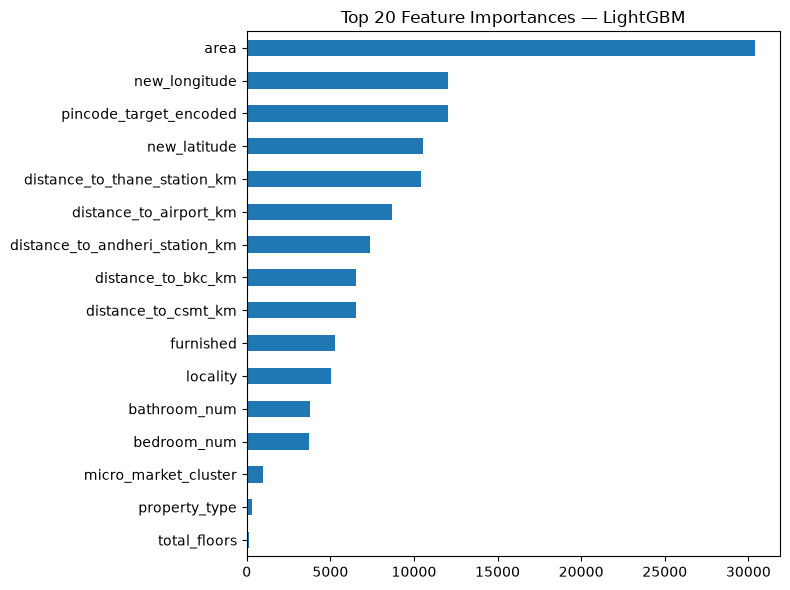

In [70]:
import matplotlib.pyplot as plt

importances = pd.Series(lgb_model.feature_importances_, index=X_train_lgb.columns)
importances.sort_values(ascending=False).head(20).plot(kind="barh", figsize=(8,6))
plt.gca().invert_yaxis()
plt.title("Top 20 Feature Importances — LightGBM")
plt.tight_layout()
plt.show()

In [71]:
print("Any NaN in dense check (sample):", np.isnan(X_train_processed.toarray()[:1000]).any())

Any NaN in dense check (sample): False


In [72]:
%pip install optuna 
import optuna
from sklearn.model_selection import KFold

   ---------------------------------------- 0.0/2.2 MB ? eta -:--:--
   --------- ------------------------------ 0.5/2.2 MB 3.8 MB/s eta 0:00:01
   ----------------------------- ---------- 1.6/2.2 MB 4.7 MB/s eta 0:00:01
   ---------------------------------- ----- 1.8/2.2 MB 3.5 MB/s eta 0:00:01
   ---------------------------------------- 2.2/2.2 MB 3.3 MB/s  0:00:00

   ---------------------------------------- 0/6 [tqdm]
   ---------------------------------------- 0/6 [tqdm]
   ---------------------------------------- 0/6 [tqdm]
   ---------------------------------------- 0/6 [tqdm]
   ---------------------------------------- 0/6 [tqdm]
   ---------------------------------------- 0/6 [tqdm]
   ---------------------------------------- 0/6 [tqdm]
   ------ --------------------------------- 1/6 [sqlalchemy]
   ------ --------------------------------- 1/6 [sqlalchemy]
   ------ --------------------------------- 1/6 [sqlalchemy]
   ------ --------------------------------- 1/6 [sqlalchemy]



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip
c:\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
def lgb_objective(trial):
    params = {
        "objective": "regression",
        "metric": "rmse",
        "verbosity": -1,
        "n_estimators": trial.suggest_int("n_estimators", 500, 3000, step=100),
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.1, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 20, 150),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        "random_state": 42,
        "n_jobs": -1,
    }

    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    fold_rmses = []

    for train_idx, val_idx in kf.split(X_train_lgb):
        X_tr = X_train_lgb.iloc[train_idx]
        X_val = X_train_lgb.iloc[val_idx]
        y_tr = y_train.iloc[train_idx]
        y_val = y_train.iloc[val_idx]

        model = lgb.LGBMRegressor(**params)
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            categorical_feature=cat_cols,
            callbacks=[lgb.early_stopping(50, verbose=False)]
        )

        preds = np.expm1(model.predict(X_val))
        actual = np.expm1(y_val)
        rmse = np.sqrt(mean_squared_error(actual, preds))
        fold_rmses.append(rmse)

    return np.mean(fold_rmses)


lgb_study = optuna.create_study(direction="minimize", study_name="lgb_tuning")
lgb_study.optimize(lgb_objective, n_trials=40, show_progress_bar=True)

print("Best LightGBM CV RMSE:", lgb_study.best_value)
print("Best LightGBM params:", lgb_study.best_params)

In [74]:
best_lgb_params = lgb_study.best_params
best_lgb_params.update({
    "objective": "regression",
    "metric": "rmse",
    "verbosity": -1,
    "random_state": 42,
    "n_jobs": -1,
})

lgb_best_model = lgb.LGBMRegressor(**best_lgb_params)
lgb_best_model.fit(
    X_train_lgb, y_train,
    eval_set=[(X_test_lgb, y_test)],
    categorical_feature=cat_cols,
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)]
)

preds = np.expm1(lgb_best_model.predict(X_test_lgb))
actual = np.expm1(y_test)
rmse = np.sqrt(mean_squared_error(actual, preds))
mae = mean_absolute_error(actual, preds)
r2 = r2_score(actual, preds)

results["LightGBM (Tuned)"] = {"RMSE": rmse, "MAE": mae, "R2": r2}
print(f"--- LightGBM (Tuned) ---\nRMSE: {rmse:,.2f}\nMAE: {mae:,.2f}\nR2: {r2:.4f}")

c:\Python314\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[2199]	valid_0's rmse: 0.231689
--- LightGBM (Tuned) ---
RMSE: 11,245,468.30
MAE: 3,578,484.29
R2: 0.8692


In [ ]:
import time

def xgb_objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 300, 1200, step=100),   # reduced range
        "learning_rate": trial.suggest_float("learning_rate", 0.02, 0.15, log=True),  # raised lower bound
        "max_depth": trial.suggest_int("max_depth", 3, 8),   # reduced from 12
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 20),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        "random_state": 42,
        "n_jobs": -1,
        "eval_metric": "rmse",
        "tree_method": "hist",     # <-- big speed fix
    }

    kf = KFold(n_splits=3, shuffle=True, random_state=42)   # 5 -> 3 folds for tuning speed
    fold_rmses = []

    X_arr = X_train_processed
    y_arr = y_train.reset_index(drop=True)

    for train_idx, val_idx in kf.split(X_arr):
        X_tr, X_val = X_arr[train_idx], X_arr[val_idx]
        y_tr, y_val = y_arr.iloc[train_idx], y_arr.iloc[val_idx]

        model = XGBRegressor(**params, early_stopping_rounds=30)
        model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)

        preds = np.expm1(model.predict(X_val))
        actual = np.expm1(y_val)
        rmse = np.sqrt(mean_squared_error(actual, preds))
        fold_rmses.append(rmse)

    return np.mean(fold_rmses)


# Add a pruner so bad trials get killed early instead of running to completion
xgb_study = optuna.create_study(
    direction="minimize",
    study_name="xgb_tuning",
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=2)
)

start = time.time()
xgb_study.optimize(xgb_objective, n_trials=20, show_progress_bar=True)  # 40 -> 20 trials first
print(f"Total time: {(time.time()-start)/60:.1f} min")
print("Best XGBoost CV RMSE:", xgb_study.best_value)
print("Best XGBoost params:", xgb_study.best_params)

In [77]:
best_xgb_params = xgb_study.best_params
best_xgb_params.update({
    "random_state": 42,
    "n_jobs": -1,
    "eval_metric": "rmse",
})

xgb_best_model = XGBRegressor(**best_xgb_params, early_stopping_rounds=50)
xgb_best_model.fit(
    X_train_processed, y_train,
    eval_set=[(X_test_processed, y_test)],
    verbose=False
)

preds = np.expm1(xgb_best_model.predict(X_test_processed))
actual = np.expm1(y_test)
rmse = np.sqrt(mean_squared_error(actual, preds))
mae = mean_absolute_error(actual, preds)
r2 = r2_score(actual, preds)

results["XGBoost (Tuned)"] = {"RMSE": rmse, "MAE": mae, "R2": r2}
print(f"--- XGBoost (Tuned) ---\nRMSE: {rmse:,.2f}\nMAE: {mae:,.2f}\nR2: {r2:.4f}")

--- XGBoost (Tuned) ---
RMSE: 13,609,286.43
MAE: 3,896,450.10
R2: 0.8085


In [78]:
comparison_df = pd.DataFrame(results).T.sort_values("RMSE")
print(comparison_df)

                           RMSE           MAE        R2
LightGBM (Tuned)   1.124547e+07  3.578484e+06  0.869227
Random Forest      1.187309e+07  3.565325e+06  0.854222
LightGBM           1.212604e+07  3.562720e+06  0.847944
XGBoost            1.274960e+07  3.904823e+06  0.831904
XGBoost (Tuned)    1.360929e+07  3.896450e+06  0.808471
Ridge Regression   1.938443e+07  5.373116e+06  0.611429
Linear Regression  2.065346e+07  5.235648e+06  0.558887


In [81]:
import joblib

models = {
    "linear_regression": lin_reg,
    "ridge": ridge,
    "random_forest": rf,
    "lightgbm": lgb_model,
    "xgboost": xgb
}

for name, model in models.items():
    joblib.dump(model, f"models/{name}.pkl")

# Save preprocessing objects too
joblib.dump(preprocessor, "models/preprocessor.pkl")
joblib.dump(kmeans, "models/kmeans.pkl")

print("All models and preprocessing objects saved successfully!")

All models and preprocessing objects saved successfully!


In [80]:
import os

print(os.getcwd())

c:\Users\HP\Desktop\Field project\Data
